# Staff Optimization Analysis
### District Headquarters Hospital, Paralakhemundi — Gajapati District, Odisha, India (761200)
**Coordinates:** 18.7783° N, 84.0937° E

This notebook reproduces, end-to-end, the staffing-optimization analysis behind the
*Staff Optimization Report*: it loads the shift-wise patient-inflow dataset and the
staff roster dataset, computes **ideal staff counts** for Doctors, Nurses,
Pharmacists, and Lab Technicians against two staff-to-patient ratio benchmarks
(**Good** and **Target**), measures the **staffing gap** for every shift over the
3-year period, and produces a **right-sizing recruitment plan**.

**Analysis sequence:**
1. Setup & Data Loading
2. Ratio Standards & Core Formula
3. Current Roster → Shift Allocation Model
4. Compute Ideal Staff & Gaps (per shift record)
5. Role-wise Findings
6. Shift-wise Findings
7. Seasonal (Monsoon) Trend
8. Right-Sizing / Recruitment Plan
9. Key Findings Summary


## 1. Setup & Data Loading

In [1]:
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

COLORS = {
    "navy": "#1B3A5C", "teal": "#1E7A78", "coral": "#D9603B",
    "amber": "#D9A441", "grey": "#9AA5B1", "light": "#EAF0F4",
}
pd.set_option("display.float_format", lambda x: f"{x:,.1f}")


In [2]:
# Data files — place shift_dataset_3years.json and staff_dataset.json
# in the same directory as this notebook (or edit the paths below).
SHIFT_DATA_PATH = "shift_dataset_3years.json"
STAFF_DATA_PATH = "staff_dataset.json"

with open(SHIFT_DATA_PATH) as f:
    shift_records = json.load(f)

with open(STAFF_DATA_PATH) as f:
    staff_records = json.load(f)

df = pd.DataFrame(shift_records)
df["date"] = pd.to_datetime(df["date"])

staff_df = pd.DataFrame(staff_records)

print(f"Shift records: {len(df):,}  |  Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Staff records: {len(staff_df):,}")
df.head()


Shift records: 3,291  |  Date range: 2023-08-04 to 2026-08-04
Staff records: 325


,id,date,year,month,day_of_week,shift_type,patient_inflow,weather,is_holiday,is_local_event
0,1,2023-08-04,2023,8,Friday,Morning,1141,Normal,False,False
1,2,2023-08-04,2023,8,Friday,Evening,560,Normal,False,False
2,3,2023-08-04,2023,8,Friday,Night,289,Normal,False,False
3,4,2023-08-05,2023,8,Saturday,Morning,938,Rain,False,False
4,5,2023-08-05,2023,8,Saturday,Evening,542,Rain,False,False


In [3]:
# Current sanctioned headcount per role
role_totals = staff_df.groupby("role")["id"].count().to_dict()
role_totals


{'Doctor': 125, 'Lab Technician': 20, 'Nurse': 160, 'Pharmacist': 20}

## 2. Ratio Standards & Core Formula

Two staff-to-patient ratio benchmarks are used:

| Role | Good Ratio | Target Ratio |
|---|---|---|
| Doctor | 1 : 50 | 1 : 20 |
| Nurse | 1 : 20 | 1 : 6 |
| Pharmacist | 1 : 100 | 1 : 75 |
| Lab Technician | 1 : 100 | 1 : 40 |

**Core formula**, applied to every shift record:

$$\text{Ideal Staff (role)} = \frac{\text{Patient Inflow (shift)}}{\text{Ratio (role)}}$$

$$\text{Staffing Gap (role)} = \text{Actual Staff on Duty} - \text{Ideal Staff}$$

A **negative gap** means understaffing relative to that ratio; a **positive gap** means surplus capacity.


In [4]:
ROLES = ["Doctor", "Nurse", "Pharmacist", "Lab Technician"]

GOOD_RATIO = {
    "Doctor": 50,
    "Nurse": 20,
    "Pharmacist": 100,
    "Lab Technician": 100,
}
TARGET_RATIO = {
    "Doctor": 20,
    "Nurse": 6,
    "Pharmacist": 75,
    "Lab Technician": 40,
}

ratio_table = pd.DataFrame({
    "Good Ratio (1 : n)": GOOD_RATIO,
    "Target Ratio (1 : n)": TARGET_RATIO,
})
ratio_table


,Good Ratio (1 : n),Target Ratio (1 : n)
Doctor,50,20
Nurse,20,6
Pharmacist,100,75
Lab Technician,100,40


## 3. Current Roster → Shift Allocation Model

`staff_dataset.json` records total sanctioned headcount per role but not a shift
assignment. To benchmark "actual" staffing per shift, the sanctioned pool for each
role is distributed across Morning / Evening / Night using a duty-roster split.
Night shift is given a higher share of the workforce than its patient share alone
would justify, reflecting the real-world need for minimum round-the-clock safety
coverage.


In [5]:
SHIFT_ALLOC_PCT = {
    "Doctor":          {"Morning": 0.50, "Evening": 0.30, "Night": 0.20},
    "Nurse":           {"Morning": 0.45, "Evening": 0.32, "Night": 0.23},
    "Pharmacist":      {"Morning": 0.50, "Evening": 0.30, "Night": 0.20},
    "Lab Technician":  {"Morning": 0.50, "Evening": 0.30, "Night": 0.20},
}

SHIFTS = ["Morning", "Evening", "Night"]

ACTUAL_STAFF_PER_SHIFT = {}
for role in ROLES:
    total = role_totals.get(role, 0)
    counts, running = {}, 0
    for i, sh in enumerate(SHIFTS):
        if i < len(SHIFTS) - 1:
            c = round(total * SHIFT_ALLOC_PCT[role][sh])
            counts[sh] = c
            running += c
        else:
            counts[sh] = total - running
    ACTUAL_STAFF_PER_SHIFT[role] = counts

actual_roster_table = pd.DataFrame(ACTUAL_STAFF_PER_SHIFT).T
actual_roster_table["Total"] = actual_roster_table.sum(axis=1)
actual_roster_table


,Morning,Evening,Night,Total
Doctor,62,38,25,125
Nurse,72,51,37,160
Pharmacist,10,6,4,20
Lab Technician,10,6,4,20


## 4. Compute Ideal Staff & Gaps (per shift record)

In [6]:
def role_key(role):
    return role.lower().replace(" ", "_")

for role in ROLES:
    k = role_key(role)
    df[f"ideal_{k}_good"]   = df["patient_inflow"] / GOOD_RATIO[role]
    df[f"ideal_{k}_target"] = df["patient_inflow"] / TARGET_RATIO[role]
    df[f"actual_{k}"]       = df["shift_type"].map(ACTUAL_STAFF_PER_SHIFT[role])
    df[f"gap_good_{k}"]     = df[f"actual_{k}"] - df[f"ideal_{k}_good"]
    df[f"gap_target_{k}"]   = df[f"actual_{k}"] - df[f"ideal_{k}_target"]

df["month_num"]  = df["date"].dt.month
df["month_name"] = df["date"].dt.strftime("%b")
df["year"]       = df["date"].dt.year

df[["date", "shift_type", "patient_inflow",
    "ideal_nurse_target", "actual_nurse", "gap_target_nurse"]].head(10)


,date,shift_type,patient_inflow,ideal_nurse_target,actual_nurse,gap_target_nurse
0,2023-08-04,Morning,1141,190.2,72,-118.2
1,2023-08-04,Evening,560,93.3,51,-42.3
2,2023-08-04,Night,289,48.2,37,-11.2
3,2023-08-05,Morning,938,156.3,72,-84.3
4,2023-08-05,Evening,542,90.3,51,-39.3
5,2023-08-05,Night,276,46.0,37,-9.0
6,2023-08-06,Morning,949,158.2,72,-86.2
7,2023-08-06,Evening,478,79.7,51,-28.7
8,2023-08-06,Night,238,39.7,37,-2.7
9,2023-08-07,Morning,1258,209.7,72,-137.7


## 5. Role-wise Findings

In [7]:
role_summary = {}
for role in ROLES:
    k = role_key(role)
    role_summary[role] = {
        "current_headcount": role_totals.get(role, 0),
        "avg_actual_per_shift": df[f"actual_{k}"].mean(),
        "avg_ideal_good": df[f"ideal_{k}_good"].mean(),
        "avg_ideal_target": df[f"ideal_{k}_target"].mean(),
        "avg_gap_target": df[f"gap_target_{k}"].mean(),
        "pct_understaffed_target": (df[f"gap_target_{k}"] < 0).mean() * 100,
        "pct_understaffed_good": (df[f"gap_good_{k}"] < 0).mean() * 100,
        "worst_gap_target": df[f"gap_target_{k}"].min(),
    }

role_summary_df = pd.DataFrame(role_summary).T
role_summary_df


,current_headcount,avg_actual_per_shift,avg_ideal_good,avg_ideal_target,avg_gap_target,pct_understaffed_target,pct_understaffed_good,worst_gap_target
Doctor,125.0,41.7,12.0,30.0,11.7,1.2,0.0,-11.0
Nurse,160.0,53.3,30.0,99.9,-46.6,94.2,0.0,-171.5
Pharmacist,20.0,6.7,6.0,8.0,-1.3,68.9,22.6,-9.5
Lab Technician,20.0,6.7,6.0,15.0,-8.3,99.8,22.6,-26.5


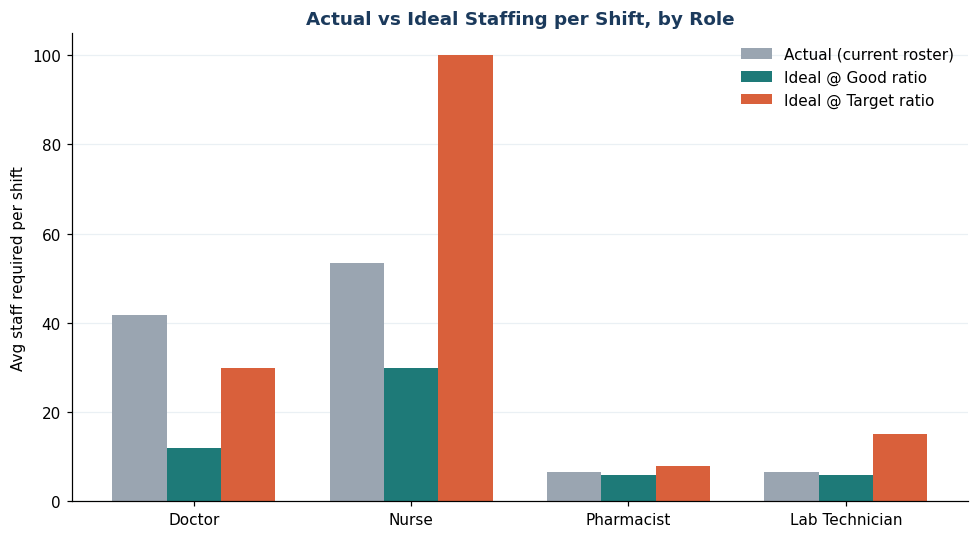

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(ROLES))
width = 0.25

actual_vals = [role_summary[r]["avg_actual_per_shift"] for r in ROLES]
good_vals   = [role_summary[r]["avg_ideal_good"] for r in ROLES]
target_vals = [role_summary[r]["avg_ideal_target"] for r in ROLES]

ax.bar(x - width, actual_vals, width, label="Actual (current roster)", color=COLORS["grey"])
ax.bar(x,          good_vals,   width, label="Ideal @ Good ratio",      color=COLORS["teal"])
ax.bar(x + width,  target_vals, width, label="Ideal @ Target ratio",    color=COLORS["coral"])

ax.set_xticks(x); ax.set_xticklabels(ROLES)
ax.set_ylabel("Avg staff required per shift")
ax.set_title("Actual vs Ideal Staffing per Shift, by Role", fontweight="bold", color=COLORS["navy"])
ax.legend(frameon=False)
ax.grid(axis="y", color=COLORS["light"])
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


**Reading the chart:** Doctors show a comfortable surplus against the Target ratio.
Nurses show the starkest shortfall — the Target ratio (1:6) implies roughly double
the current nursing roster. Pharmacists and Lab Technicians are adequate against
the Good ratio but fall short of Target, Lab Technicians more so.


## 6. Shift-wise Findings

In [9]:
shift_summary = {}
for sh in SHIFTS:
    sub = df[df["shift_type"] == sh]
    shift_summary[sh] = {"avg_patients": sub["patient_inflow"].mean()}
    for role in ROLES:
        k = role_key(role)
        shift_summary[sh][f"avg_gap_target_{k}"] = sub[f"gap_target_{k}"].mean()

shift_summary_df = pd.DataFrame(shift_summary).T
shift_summary_df


,avg_patients,avg_gap_target_doctor,avg_gap_target_nurse,avg_gap_target_pharmacist,avg_gap_target_lab_technician
Morning,989.1,12.5,-92.8,-3.2,-14.7
Evening,540.6,11.0,-39.1,-1.2,-7.5
Night,269.3,11.5,-7.9,0.4,-2.7


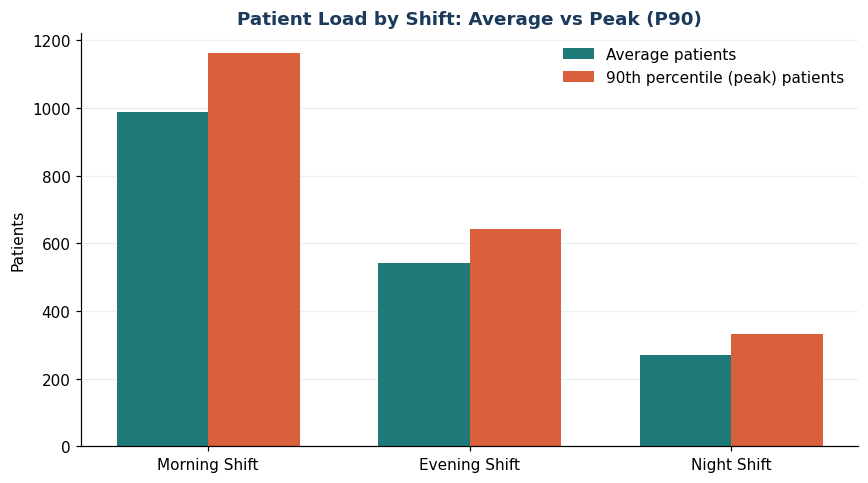

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
avg_p = [df[df.shift_type == s]["patient_inflow"].mean() for s in SHIFTS]
p90_p = [df[df.shift_type == s]["patient_inflow"].quantile(0.90) for s in SHIFTS]
x = np.arange(len(SHIFTS)); width = 0.35

ax.bar(x - width/2, avg_p, width, label="Average patients", color=COLORS["teal"])
ax.bar(x + width/2, p90_p, width, label="90th percentile (peak) patients", color=COLORS["coral"])
ax.set_xticks(x); ax.set_xticklabels([f"{s} Shift" for s in SHIFTS])
ax.set_ylabel("Patients")
ax.set_title("Patient Load by Shift: Average vs Peak (P90)", fontweight="bold", color=COLORS["navy"])
ax.legend(frameon=False)
ax.grid(axis="y", color=COLORS["light"])
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


**Reading the chart:** Morning is the dominant shift by patient volume (~55% shift
factor), which means Morning-shift staffing gaps dominate the daily deficit —
particularly for Nurses.


## 7. Seasonal (Monsoon) Trend

In [11]:
monthly = df.groupby("month_num").agg(
    avg_patients_per_shift=("patient_inflow", "mean"),
    avg_gap_doctor=("gap_target_doctor", "mean"),
    avg_gap_nurse=("gap_target_nurse", "mean"),
    avg_gap_pharmacist=("gap_target_pharmacist", "mean"),
    avg_gap_lab=("gap_target_lab_technician", "mean"),
)
monthly.index = [pd.Timestamp(2026, m, 1).strftime("%b") for m in monthly.index]
monthly


,avg_patients_per_shift,avg_gap_doctor,avg_gap_nurse,avg_gap_pharmacist,avg_gap_lab
Jan,574.8,12.9,-42.5,-1.0,-7.7
Feb,552.3,14.1,-38.7,-0.7,-7.1
Mar,555.8,13.9,-39.3,-0.7,-7.2
Apr,605.8,11.4,-47.6,-1.4,-8.5
May,616.0,10.9,-49.3,-1.5,-8.7
Jun,631.0,10.1,-51.8,-1.7,-9.1
Jul,671.6,8.1,-58.6,-2.3,-10.1
Aug,660.3,8.7,-56.7,-2.1,-9.8
Sep,630.0,10.2,-51.7,-1.7,-9.1
Oct,601.8,11.6,-47.0,-1.4,-8.4


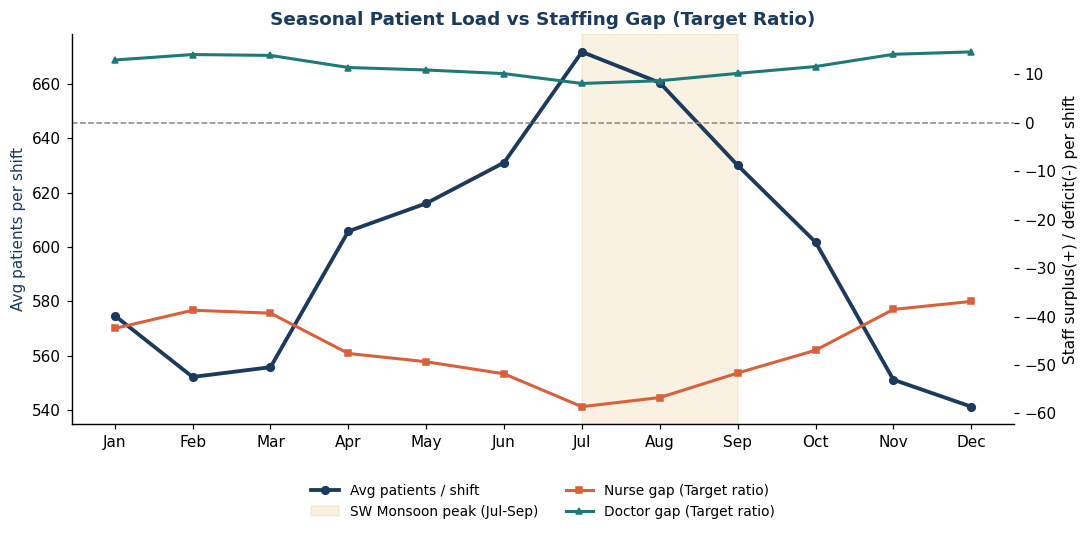

In [12]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
mt = monthly.loc[month_order]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(month_order, mt["avg_patients_per_shift"], color=COLORS["navy"], linewidth=2.5,
         marker="o", markersize=5, label="Avg patients / shift")
ax1.set_ylabel("Avg patients per shift", color=COLORS["navy"])
ax1.axvspan(6, 8, color=COLORS["amber"], alpha=0.15, label="SW Monsoon peak (Jul-Sep)")

ax2 = ax1.twinx()
ax2.plot(month_order, mt["avg_gap_nurse"], color=COLORS["coral"], linewidth=2,
         marker="s", markersize=4, label="Nurse gap (Target ratio)")
ax2.plot(month_order, mt["avg_gap_doctor"], color=COLORS["teal"], linewidth=2,
         marker="^", markersize=4, label="Doctor gap (Target ratio)")
ax2.axhline(0, color="#888888", linewidth=1, linestyle="--")
ax2.set_ylabel("Staff surplus(+) / deficit(-) per shift")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center",
           bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False, fontsize=9)
ax1.set_title("Seasonal Patient Load vs Staffing Gap (Target Ratio)", fontweight="bold", color=COLORS["navy"])
plt.tight_layout()
plt.show()


**Reading the chart:** Patient load rises from April, peaks in July during the
active South-West Monsoon, and recedes through Q4. The Nurse gap worsens in step
with this curve — the tightest point of the year. The Doctor surplus compresses
during the same window but never turns negative on average.


## 8. Right-Sizing / Recruitment Plan

Each role's roster is sized to comfortably cover the **90th-percentile (P90)**
shift patient-load at the **Target** ratio, then a **15% buffer** is added to
account for weekly offs, leave, and training days (sanctioned headcount must
exceed on-duty headcount to sustain 7-day coverage).


In [13]:
LEAVE_BUFFER = 1.15
recruitment_plan = {}

for role in ROLES:
    per_shift_need, needed_total = {}, 0
    for sh in SHIFTS:
        sub = df[df["shift_type"] == sh]
        p90_patients = sub["patient_inflow"].quantile(0.90)
        ideal_p90 = math.ceil(p90_patients / TARGET_RATIO[role])
        roster_need = math.ceil(ideal_p90 * LEAVE_BUFFER)
        per_shift_need[sh] = roster_need
        needed_total += roster_need

    current = role_totals.get(role, 0)
    recruitment_plan[role] = {
        "current_headcount": current,
        "recommended_headcount_p90": needed_total,
        "additional_hires_needed": max(0, needed_total - current),
        **{f"rec_{sh.lower()}": per_shift_need[sh] for sh in SHIFTS},
    }

recruitment_df = pd.DataFrame(recruitment_plan).T
recruitment_df


,current_headcount,recommended_headcount_p90,additional_hires_needed,rec_morning,rec_evening,rec_night
Doctor,125,126,1,68,38,20
Nurse,160,413,253,224,124,65
Pharmacist,20,36,16,19,11,6
Lab Technician,20,66,46,35,20,11


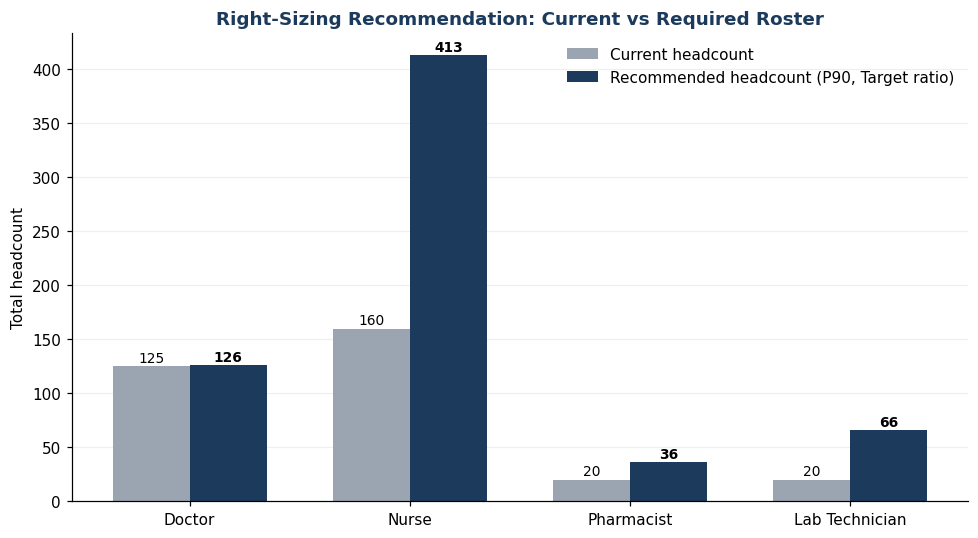

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(ROLES)); width = 0.35
current = [recruitment_plan[r]["current_headcount"] for r in ROLES]
recommended = [recruitment_plan[r]["recommended_headcount_p90"] for r in ROLES]

ax.bar(x - width/2, current, width, label="Current headcount", color=COLORS["grey"])
ax.bar(x + width/2, recommended, width, label="Recommended headcount (P90, Target ratio)", color=COLORS["navy"])
for i in range(len(ROLES)):
    ax.text(x[i]-width/2, current[i]+4, f"{current[i]}", ha="center", fontsize=9)
    ax.text(x[i]+width/2, recommended[i]+4, f"{recommended[i]}", ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(ROLES)
ax.set_ylabel("Total headcount")
ax.set_title("Right-Sizing Recommendation: Current vs Required Roster", fontweight="bold", color=COLORS["navy"])
ax.legend(frameon=False)
ax.grid(axis="y", color=COLORS["light"])
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


## 9. Key Findings Summary

In [15]:
print("="*70)
print("STAFF OPTIMIZATION — KEY FINDINGS")
print("="*70)
print(f"Period analyzed : {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Shift records   : {len(df):,}")
print(f"Avg daily patients : {df.groupby('date')['patient_inflow'].sum().mean():,.0f}")
print()
for role in ROLES:
    rp = recruitment_plan[role]
    rs = role_summary[role]
    print(f"- {role:16s}: current {rp['current_headcount']:>4} | "
          f"recommended {rp['recommended_headcount_p90']:>4} | "
          f"additional hires {rp['additional_hires_needed']:>4} | "
          f"understaffed on {rs['pct_understaffed_target']:.1f}% of shifts (Target ratio)")
print("="*70)


STAFF OPTIMIZATION — KEY FINDINGS
Period analyzed : 2023-08-04 to 2026-08-04
Shift records   : 3,291
Avg daily patients : 1,799

- Doctor          : current  125 | recommended  126 | additional hires    1 | understaffed on 1.2% of shifts (Target ratio)
- Nurse           : current  160 | recommended  413 | additional hires  253 | understaffed on 94.2% of shifts (Target ratio)
- Pharmacist      : current   20 | recommended   36 | additional hires   16 | understaffed on 68.9% of shifts (Target ratio)
- Lab Technician  : current   20 | recommended   66 | additional hires   46 | understaffed on 99.8% of shifts (Target ratio)


### Recommendations
- **Prioritize Nursing recruitment** — the largest and most consistent gap (understaffed on ~94% of shifts at Target ratio).
- **Reinforce Lab Technician capacity** — the second most understaffed category.
- **Right-size Pharmacist staffing** with a smaller, targeted addition.
- **Do not materially expand Doctor headcount** — current roster already exceeds Target-ratio needs on average.
- **Build a seasonal flex-staffing pool** for the Jul–Sep monsoon window, when deficits are worst across all roles.
- **Re-balance the shift allocation formula** — shift a few more points of staffing share to Morning, which carries the largest patient load and deficit.

### Limitations
- Patient inflow and staff roster datasets are synthetic, built to realistic regional patterns — a planning proxy, not live hospital records.
- Actual staff-per-shift is derived from total sanctioned headcount via an assumed roster-allocation split, since the source roster has no shift field.
- Ideal staff counts are a linear function of patient inflow only; real-world staffing also depends on case-mix severity, ward occupancy, and procedure load.
- The Good/Target ratios were supplied directly for this analysis, not derived from IPHS/WHO published norms.
